In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')
from linear_regression import LinearRegression

from sklearn.datasets import fetch_california_housing



In [17]:
housing = fetch_california_housing()

#Create a DataFrame - why? Ans: To understand the data better
df = pd.DataFrame(housing.data, columns = housing.feature_names)
df['Price'] = housing.target

print("Dataset Shape: ", df.shape)
print('First few rows :')
print(df.head())

print("Dataset Statistics")
print(df.describe())

Dataset Shape:  (20640, 9)
First few rows :
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  
Dataset Statistics
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.00000

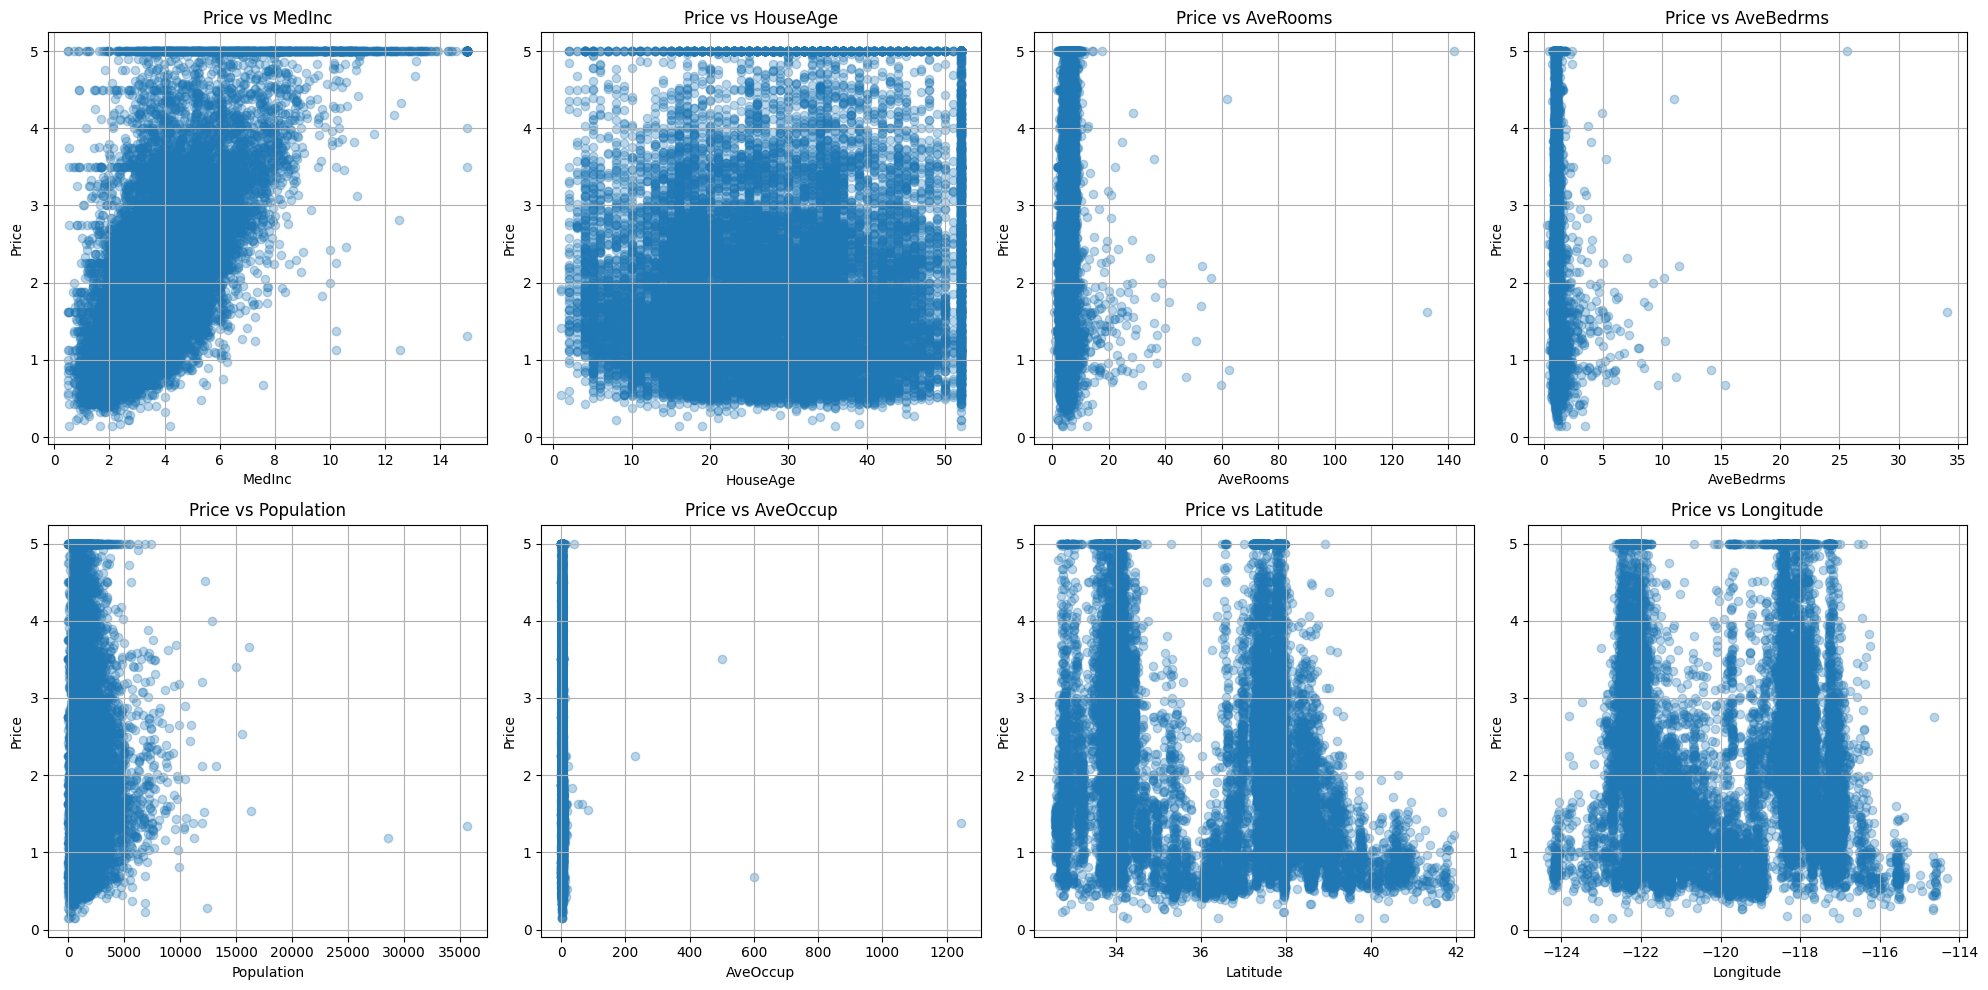

In [18]:
# Exploratory Data Analysis
fig, axes = plt.subplots(2,4, figsize = (20,10))
axes = axes.ravel() #ravel() is used to flatten the array - why? Ans: To make the plot more readable : what does flatten mean? Ans: To make the plot more readable

for i, col in enumerate(df.columns[:-1]):
    axes[i].scatter(df[col], df['Price'], alpha = 0.3)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price')
    axes[i].set_title(f'Price vs {col}')
    axes[i].grid(True)

plt.tight_layout()
plt.show()


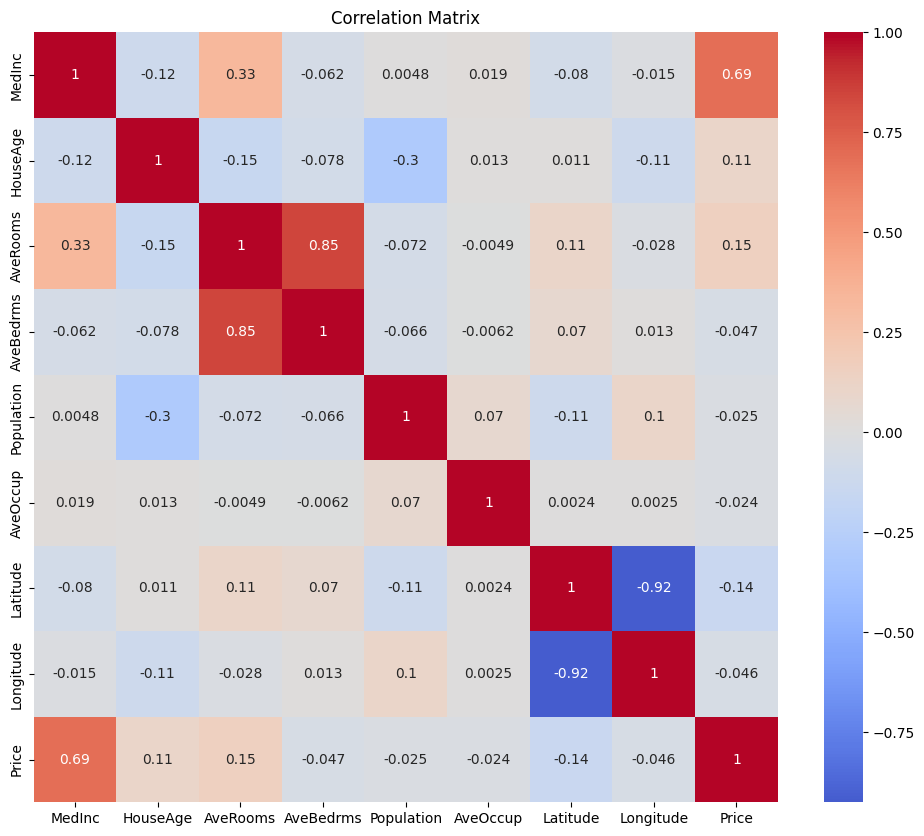

In [19]:
#Correlation Matrix - what is it? Ans: It is a matrix that shows the correlation between the features : what is correlation? Ans: It is a measure of the relationship between two variables
# why do we need to check correlation? Ans: To understand the relationship between the features and the target variable
# what is a good correlation? Ans: The closer to 1 or -1, the stronger the relationship
# what is a bad correlation? Ans: The closer to 0, the weaker the relationship
# what is a perfect correlation? Ans: The closer to 1 or -1, the stronger the relationship
# what is a perfect negative correlation? Ans: The closer to -1, the stronger the relationship
# what is a perfect positive correlation? Ans: The closer to 1, the stronger the relationship



plt.figure(figsize = (12,10))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm', center = 0) #
plt.title('Correlation Matrix')
plt.show()


Training set size: 16512 samples
Testing set size: 4128 samples

 Training the model...

 Ex : 1 - LR - alpha = 0.01
Iteration 0 : Cost =  2.7650
Iteration 100 : Cost =  0.6453
Iteration 200 : Cost =  0.3551
Iteration 300 : Cost =  0.3094
Iteration 400 : Cost =  0.2976
Iteration 500 : Cost =  0.2914
Iteration 600 : Cost =  0.2866
Iteration 700 : Cost =  0.2826
Iteration 800 : Cost =  0.2792
Iteration 900 : Cost =  0.2763

 Evaluating the model...
Training set R^2: 0.5903
Testing set R^2: 0.5672

 Ex : 2 - LR - alpha = 0.03
Iteration 0 : Cost =  2.6667
Iteration 100 : Cost =  0.3086
Iteration 200 : Cost =  0.2865
Iteration 300 : Cost =  0.2762
Iteration 400 : Cost =  0.2699
Iteration 500 : Cost =  0.2659
Iteration 600 : Cost =  0.2634
Iteration 700 : Cost =  0.2618
Iteration 800 : Cost =  0.2608
Iteration 900 : Cost =  0.2602

 Evaluating the model...
Training set R^2: 0.6113
Testing set R^2: 0.5766

 Ex : 2.1 - LR - alpha = 0.99
Iteration 0 : Cost =  0.3379
Iteration 100 : Cost =  0.26

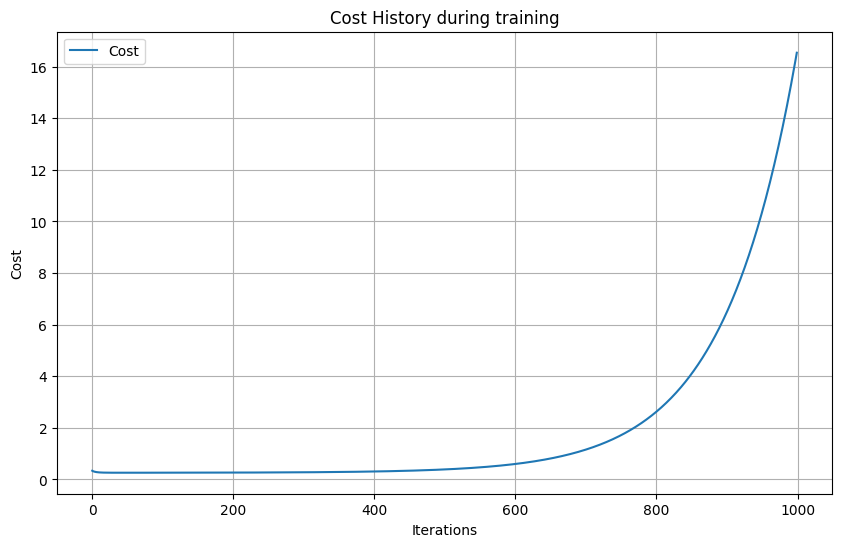


 Ex : 3 - LR - alpha = 0.1
Iteration 0 : Cost =  2.3389
Iteration 100 : Cost =  0.2735
Iteration 200 : Cost =  0.2622
Iteration 300 : Cost =  0.2598
Iteration 400 : Cost =  0.2592
Iteration 500 : Cost =  0.2590
Iteration 600 : Cost =  0.2590
Iteration 700 : Cost =  0.2590
Iteration 800 : Cost =  0.2590
Iteration 900 : Cost =  0.2590

 Evaluating the model...
Training set R^2: 0.6126
Testing set R^2: 0.5757


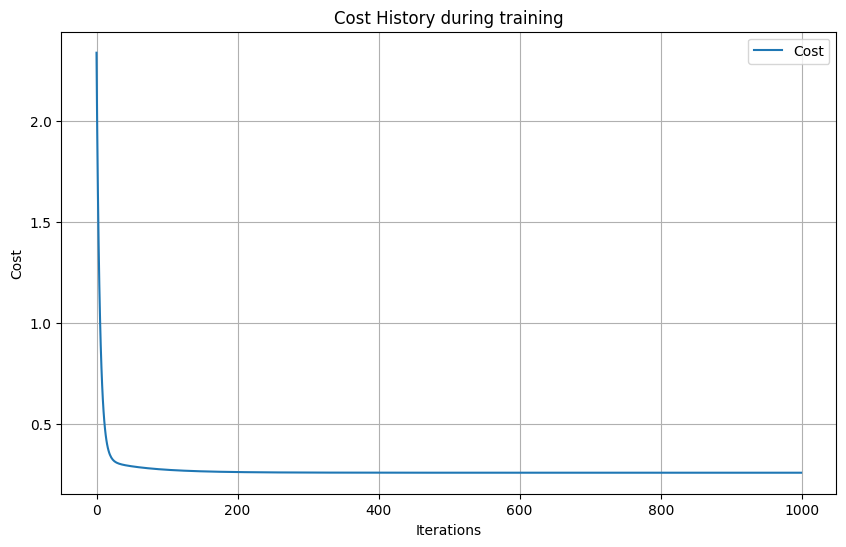

In [45]:
#Prepare the data for training
X = df.drop('Price', axis = 1).values
y = df['Price'].values

#Split the data into train/test (80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) 
# how does this work? Ans: It splits the data into training and testing sets
# what is the purpose of the random_state? Ans: To make the split reproducible : what does reproducible mean? Ans: To make the split the same every time the code is run
# why 42, does it have any special significance? Ans: No, it is just a random number
# how is the mapping done? X_train ---> y_train, X_test ---> y_test



print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Train the model

print("\n Training the model...")
print(f"{'='*50}")
print("\n Ex : 1 - LR - alpha = 0.01")
model = LinearRegression(alpha= 0.01, num_iterations= 1000, normalize = True)
model.fit(X_train, y_train)

# Evaluate the model 

print("\n Evaluating the model...")
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f"Training set R^2: {train_score:.4f}") 
# R^2 is the coefficient of determination : what is it? Ans: It is a measure of the goodness of fit of the model : 
# what does goodness of fit mean? Ans: It is a measure of how well the model fits the data
# what is the range of R^2? Ans: 0 to 1 : what does 0 mean? Ans: The model is not a good fit : what does 1 mean? Ans: The model is a perfect fit

# Myscore fore training set is 0.6126 : what does it mean? Ans: The model is a good fit for the training set, but closer to 1 means good right.? how is it good .?

print(f"Testing set R^2: {test_score:.4f}")
print(f"{'='*50}")

print(f"{'='*50}")
print("\n Ex : 2 - LR - alpha = 0.03")
model = LinearRegression(alpha= 0.03, num_iterations= 1000, normalize = True)
model.fit(X_train, y_train)

# Evaluate the model 

print("\n Evaluating the model...")
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f"Training set R^2: {train_score:.4f}") 
# R^2 is the coefficient of determination : what is it? Ans: It is a measure of the goodness of fit of the model : 
# what does goodness of fit mean? Ans: It is a measure of how well the model fits the data
# what is the range of R^2? Ans: 0 to 1 : what does 0 mean? Ans: The model is not a good fit : what does 1 mean? Ans: The model is a perfect fit

# Myscore fore training set is 0.6126 : what does it mean? Ans: The model is a good fit for the training set, but closer to 1 means good right.? how is it good .?

print(f"Testing set R^2: {test_score:.4f}")
print(f"{'='*50}")

print(f"{'='*50}")

print("\n Ex : 2.1 - LR - alpha = 0.99")
model = LinearRegression(alpha= 0.99, num_iterations= 1000, normalize = True)
model.fit(X_train, y_train)

# Evaluate the model 

print("\n Evaluating the model...")
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f"Training set R^2: {train_score:.4f}") 
# R^2 is the coefficient of determination : what is it? Ans: It is a measure of the goodness of fit of the model : 
# what does goodness of fit mean? Ans: It is a measure of how well the model fits the data
# what is the range of R^2? Ans: 0 to 1 : what does 0 mean? Ans: The model is not a good fit : what does 1 mean? Ans: The model is a perfect fit

# Myscore fore training set is 0.6126 : what does it mean? Ans: The model is a good fit for the training set, but closer to 1 means good right.? how is it good .?

print(f"Testing set R^2: {test_score:.4f}")


#visualize the predictions
model.plot_cost_history()
print(f"{'='*50}")

print(f"{'='*50}")

print("\n Ex : 3 - LR - alpha = 0.1")
model = LinearRegression(alpha= 0.1, num_iterations= 1000, normalize = True)
model.fit(X_train, y_train)

# Evaluate the model 

print("\n Evaluating the model...")
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f"Training set R^2: {train_score:.4f}") 
# R^2 is the coefficient of determination : what is it? Ans: It is a measure of the goodness of fit of the model : 
# what does goodness of fit mean? Ans: It is a measure of how well the model fits the data
# what is the range of R^2? Ans: 0 to 1 : what does 0 mean? Ans: The model is not a good fit : what does 1 mean? Ans: The model is a perfect fit

# Myscore fore training set is 0.6126 : what does it mean? Ans: The model is a good fit for the training set, but closer to 1 means good right.? how is it good .?

print(f"Testing set R^2: {test_score:.4f}")


#visualize the predictions
model.plot_cost_history()
print(f"{'='*50}")

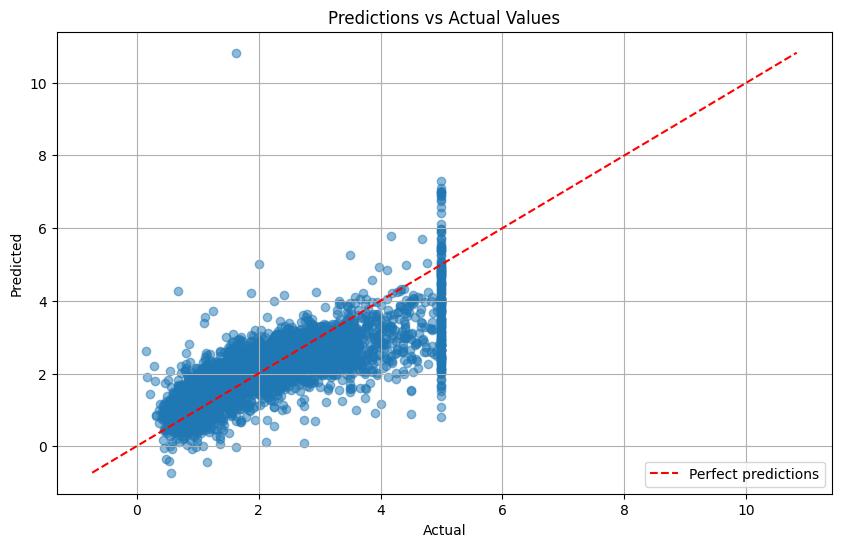

In [21]:
# Plot predicted vs actual values
model.plot_predictions_vs_actual(X_test, y_test)


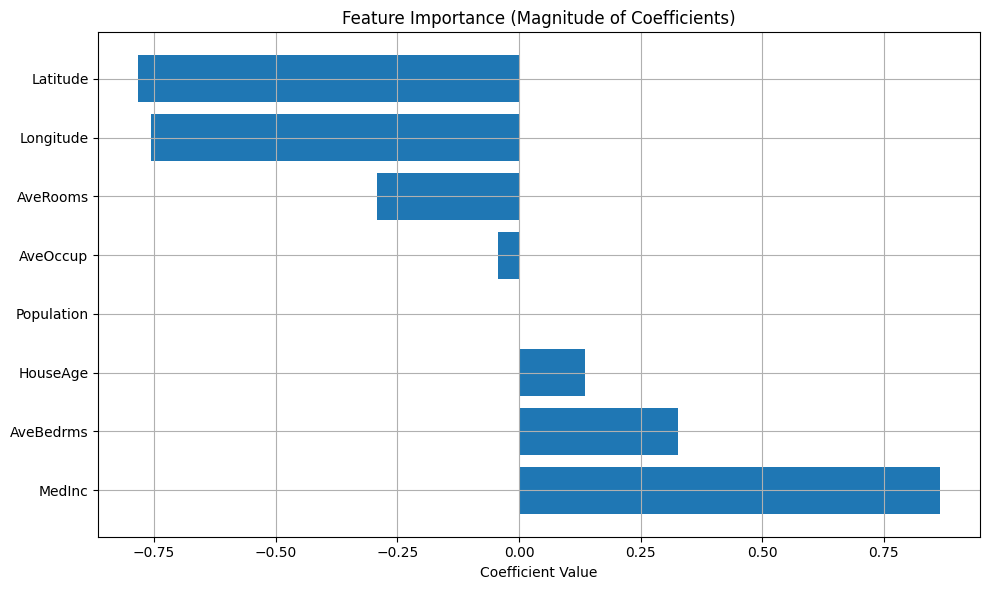


Feature Importance:
      Feature  Coefficient
0      MedInc     0.865187
3   AveBedrms     0.327224
1    HouseAge     0.136484
4  Population     0.002390
5    AveOccup    -0.042380
2    AveRooms    -0.292650
7   Longitude    -0.755139
6    Latitude    -0.782014


In [22]:
# Feature Importance (magnitude of the coefficients) 
# what is it? Ans: It is a measure of the importance of the features in the model : what is importance? Ans: It is a measure of how much the feature contributes to the model
# why do we need to check feature importance? Ans: To understand the importance of the features in the model
# what is a good feature importance? Ans: The closer to 1 or -1, the stronger the relationship: relationship between feature and target variable
# what is a bad feature importance? Ans: The closer to 0, the weaker the relationship
# what is a perfect feature importance? Ans: The closer to 1 or -1, the stronger the relationship
# what is a perfect negative feature importance? Ans: The closer to -1, the stronger the relationship
# what is a perfect positive feature importance? Ans: The closer to 1, the stronger the relationship

#is this a dataframe? Ans: Yes, it is a dataframe
feature_importance = pd.DataFrame({
    'Feature' : housing.feature_names,
    'Coefficient' : model.theta[1:]
})

feature_importance = feature_importance.sort_values('Coefficient', ascending = False) 
# Why is this sorted? Ans: To understand the importance of the features in the model
# What does ascending mean? Ans: The higher the coefficient, the more important the feature
# What does descending mean? Ans: The lower the coefficient, the more important the feature

# Plot the feature importance
plt.figure(figsize = (10,6))
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Feature Importance (Magnitude of Coefficients)')
plt.grid(True)
plt.tight_layout()
plt.show()

# What does this tell us? Ans: The feature with the highest coefficient is the most important feature in the model
print("\nFeature Importance:")
print(feature_importance)

# What is medinc? Ans: Median income of the house


In [23]:
# Comparing with sklearn in built linear regression model
from sklearn.linear_model import LinearRegression as SKLinearRegression

sk_model = SKLinearRegression()
sk_model.fit(X_train, y_train)
sk_score = sk_model.score(X_test, y_test)

print(f"\n{'='*50}")
print("Comparison with scikit-learn:")
print(f"Your model R^2: {test_score:.4f}")
print(f"sklearn R^2: {sk_score:.4f}")
print(f"Difference: {abs(test_score - sk_score):.6f}")
print(f"{'='*50}")


Comparison with scikit-learn:
Your model R^2: 0.5766
sklearn R^2: 0.5758
Difference: 0.000796


theta_final: [ 2.07194694  0.86518739  0.13648361 -0.29264951  0.3272244   0.00238967
 -0.04237957 -0.78201386 -0.75513895]


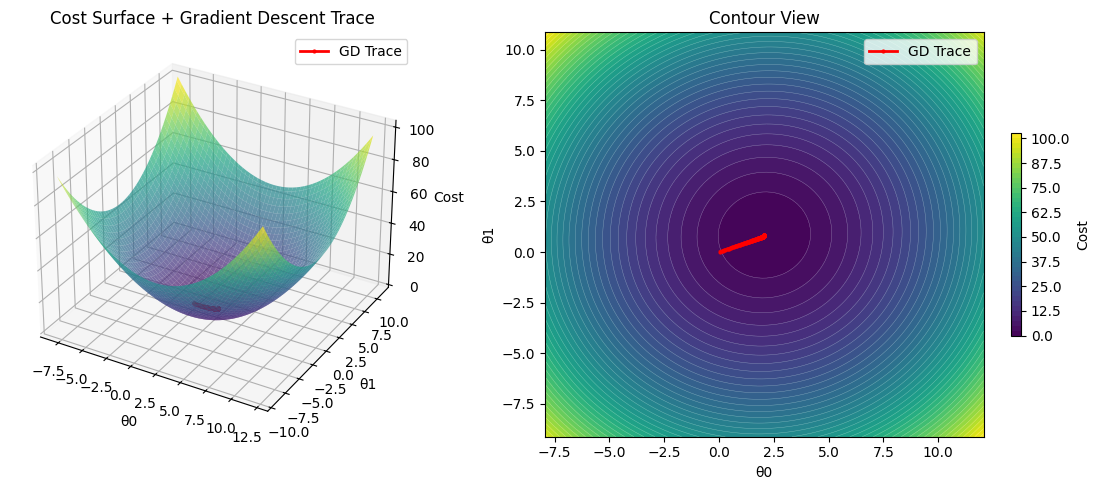

In [24]:
model.plot_cost_surface(X_test, y_test, theta_i = 0 , theta_j = 1)
# X_test.shape

theta_final: [ 2.07194694  0.86518739  0.13648361 -0.29264951  0.3272244   0.00238967
 -0.04237957 -0.78201386 -0.75513895]


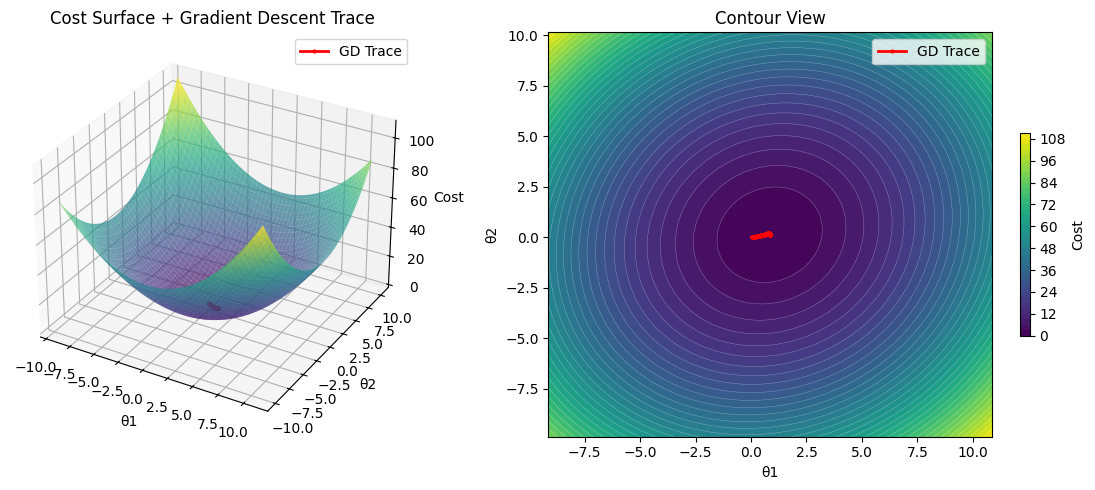

In [25]:
model.plot_cost_surface(X_test, y_test, theta_i = 1 , theta_j = 2)

theta_final: [ 2.07194694  0.86518739  0.13648361 -0.29264951  0.3272244   0.00238967
 -0.04237957 -0.78201386 -0.75513895]


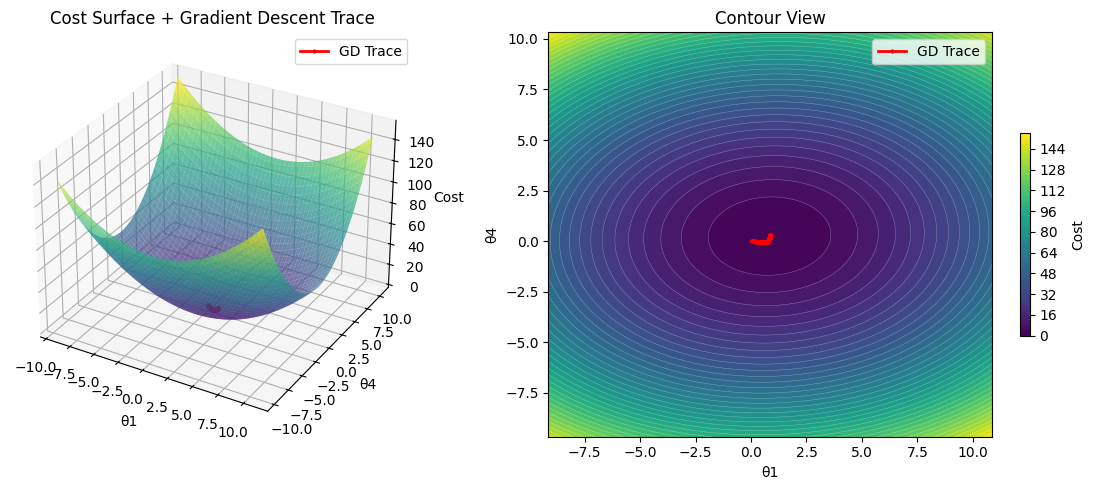

In [26]:
model.plot_cost_surface(X_test, y_test, theta_i = 1 , theta_j = 4)

theta_final: [ 2.07194694  0.86518739  0.13648361 -0.29264951  0.3272244   0.00238967
 -0.04237957 -0.78201386 -0.75513895]


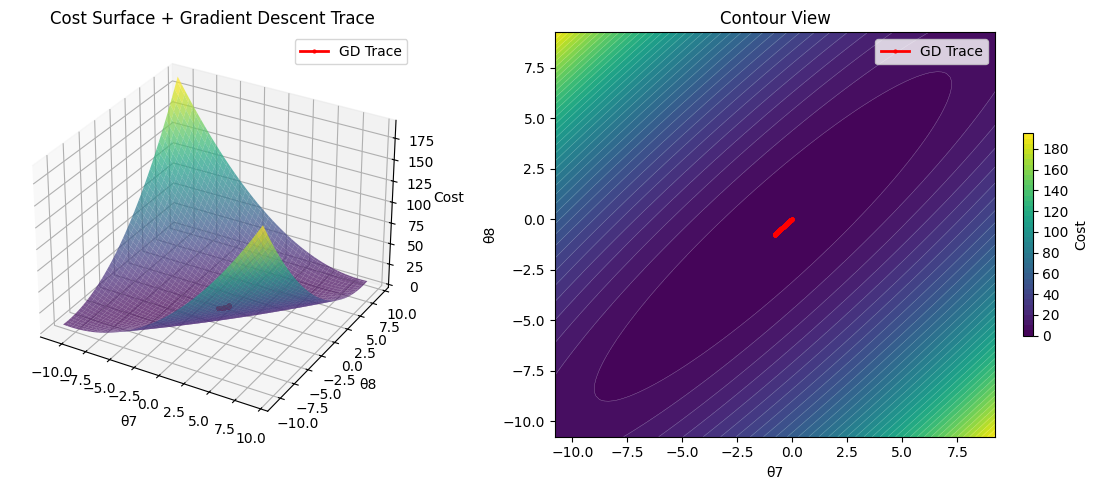

In [27]:
model.plot_cost_surface(X_test, y_test, theta_i = 7 , theta_j = 8)

theta_final: [ 2.07194694  0.86518739  0.13648361 -0.29264951  0.3272244   0.00238967
 -0.04237957 -0.78201386 -0.75513895]


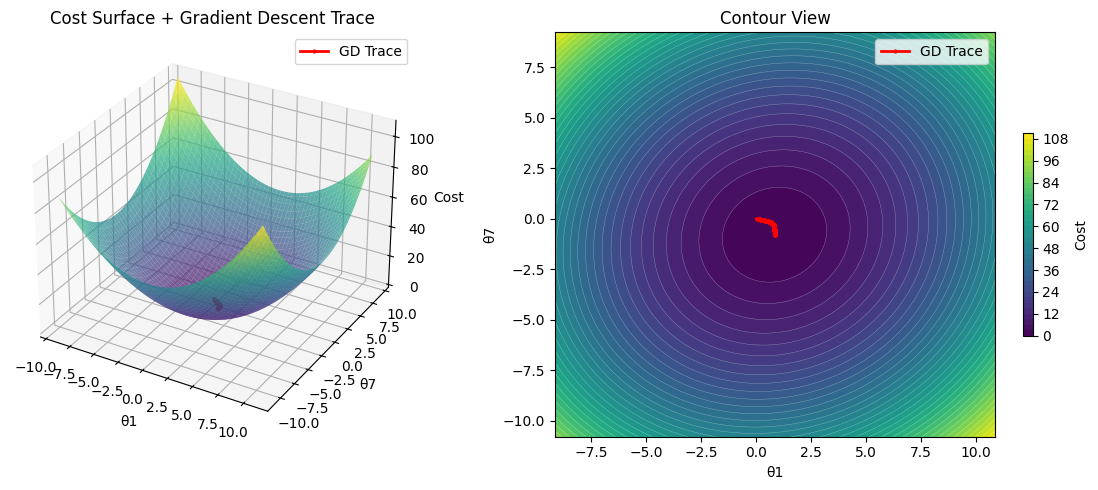

In [28]:
model.plot_cost_surface(X_test, y_test, theta_i = 1 , theta_j = 7)